In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv


# M2-Weighted — CABiLSTM-IndoBERT + Frozen BERT + Sqrt-based Class Weighting (Multilabel Wide Format)

**Ablation study: M2 (Frozen BERT) dengan tambahan Sqrt-based Class Weighting — tanpa Focal Loss.**

## Purpose (Ablation Study)
Menguji apakah class weighting saja (tanpa Focal Loss, tanpa partial unfreeze) sudah cukup menangani class imbalance pada frozen-BERT setup.

| | M2 | **M2-Weighted** |
|---|---|---|
| BERT strategy | Fully frozen | **Fully frozen** |
| Loss | Masked BCE | **Masked Weighted BCE** |
| Class weight | None | **Sqrt-normalized** |
| Focal modulation | None | None |

## Architecture:
```
Input: [CLS] review_text [SEP]
  │
  ▼
IndoBERT (ALL FROZEN) ──► V  [B, L, 768]  (no_grad always)
  │
  ▼
CABiLSTM (lr=5e-4) → Masked Mean Pooling
  │
  ▼
MLP: 1024 → 512 → 15 outputs
```

**References**: He et al. (2025); Mahajan et al. (2018).

---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
CONFIG = {
    # Model
    'model_name'      : 'indobenchmark/indobert-base-p1',
    'num_outputs'     : 15,        # 5 aspects × 3 sentiments
    'dropout'         : 0.3,
    # Tokenization
    'max_length'      : 128,
    # Training
    'batch_size'      : 16,
    'weight_decay'    : 0.01,
    'epochs'          : 10,
    'patience'        : 3,
    'warmup_ratio'    : 0.1,
    'grad_clip'       : 1.0,
    # Strictly Frozen BERT — single LR for CABiLSTM + MLP only
    'learning_rate'   : 5e-4,      # He et al. (2025) frozen-BERT LR
    # CABiLSTM architecture (He et al., 2025)
    'bilstm_hidden'   : 384,
    'attn_heads'      : 8,
    'conv_kernel'     : 5,
    'mlp_hidden_1'    : 1024,
    'mlp_hidden_2'    : 512,
    # Sqrt-based Class Weighting (no Focal Loss)
    'weight_strategy' : 'sqrt_normalized',
    'focal_gamma'     : None,      # No Focal Loss
    'seed'            : SEED,
}

ASPECTS    = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['negative', 'neutral', 'positive']   # index 0, 1, 2
SENT2ID    = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT    = {i: s for s, i in SENT2ID.items()}

DATA_PATH           = '/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv'
OUTPUT_DIR          = '/kaggle/working'
BEST_MODEL_PATH     = f'{OUTPUT_DIR}/m2weighted_best.pt'
PREDICTIONS_PATH    = f'{OUTPUT_DIR}/m2weighted_predictions.csv'
METRICS_PATH        = f'{OUTPUT_DIR}/m2weighted_metrics.json'
LOSS_PLOT_PATH      = f'{OUTPUT_DIR}/m2weighted_loss_convergence.png'
CM_PLOT_PATH        = f'{OUTPUT_DIR}/m2weighted_confusion_matrix.png'
PERASPECT_PLOT_PATH = f'{OUTPUT_DIR}/m2weighted_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<22} {v}')

Config loaded.
  model_name             indobenchmark/indobert-base-p1
  num_outputs            15
  dropout                0.3
  max_length             128
  batch_size             16
  weight_decay           0.01
  epochs                 10
  patience               3
  warmup_ratio           0.1
  grad_clip              1.0
  learning_rate          0.0005
  bilstm_hidden          384
  attn_heads             8
  conv_kernel            5
  mlp_hidden_1           1024
  mlp_hidden_2           512
  weight_strategy        sqrt_normalized
  focal_gamma            None
  seed                   42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
train_df = df[df['split'] == 'train']
print('Label distribution per aspect (train set):')
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    pos, neg, neu, noa = (counts.get(k, 0) for k in ['positive', 'negative', 'neutral', 'no_aspect'])
    sents = [c for c in [pos, neg, neu] if c > 0]
    ratio = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


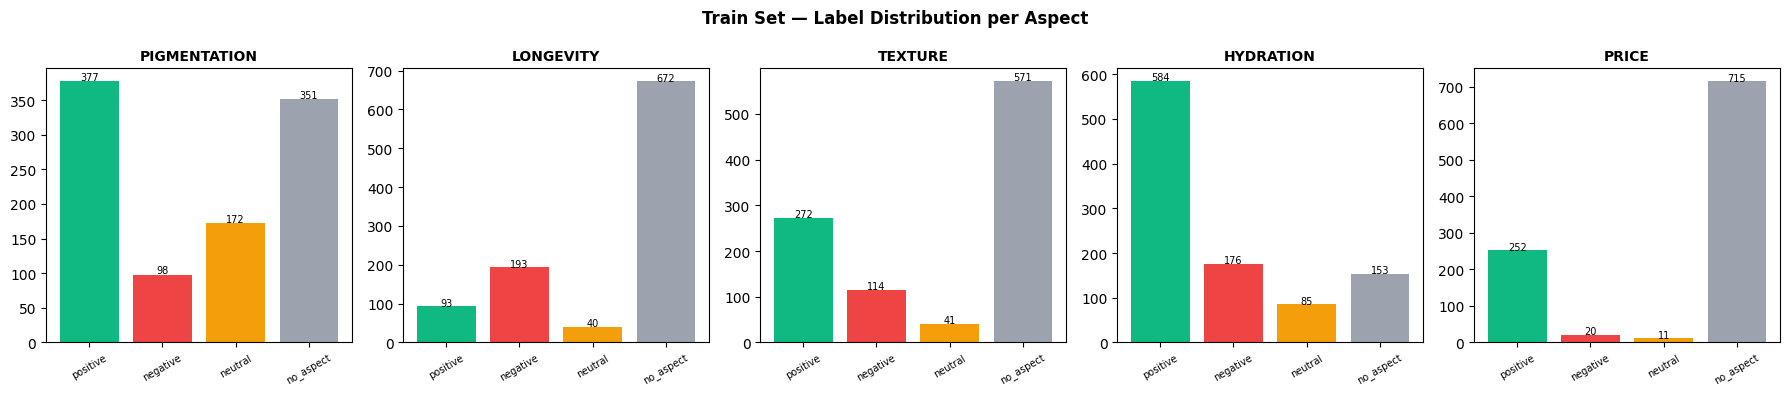

In [7]:
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4))
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v), ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):
    """
    Multilabel ABSA dataset — wide format.

    Input : [CLS] review_text [SEP]
    labels: float tensor (15,)  — one-hot per active (aspect, sentiment) slot
    mask  : float tensor (15,)  — 1.0 for slots where aspect != no_aspect

    Flat layout: [pig_neg, pig_neu, pig_pos, lon_neg, ..., pri_pos]
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.zeros(15, dtype=torch.float)
        mask   = torch.zeros(15, dtype=torch.float)

        for asp_idx, asp in enumerate(ASPECTS):
            val  = row[asp]
            base = asp_idx * 3
            if val != 'no_aspect':
                labels[base + SENT2ID[val]] = 1.0
                mask[base : base + 3]       = 1.0

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,
            'mask'          : mask,
            'review_id'     : str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

s = train_ds[0]
print(f'\nSample 0 active aspects: '
      f'{[(ASPECTS[i], SENTIMENTS[j]) for i in range(5) for j in range(3) if s["labels"][i*3+j] == 1.0]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews

Sample 0 active aspects: [('HYDRATION', 'positive')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'mask'          : torch.stack([b['mask']           for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

b = next(iter(train_loader))
print('\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'mask']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 15])  dtype=torch.float32
  mask            : torch.Size([16, 15])  dtype=torch.float32


---
## Section 6: Model Definition — CABiLSTM-IndoBERT (Strict Frozen)

Arsitektur identik dengan M2 dan M3-Frozen. BERT sepenuhnya frozen — static feature extractor.

In [12]:
class CABiLSTMCore(nn.Module):
    """
    CABiLSTM deep implicit feature extraction layer (He et al., 2025 Section 3.3).

    Pipeline:
      1. Dual-layer BiLSTM → preserve outputs {V, F1, B1, F2, B2}
      2. MHSA on each of 5 feature groups independently
      3. Channel-wise concat {A1..A5} → Conv2d (5→1) → ReLU

    Input : x  [B, L, hidden_dim]
    Output: Co [B, L, hidden_dim]
    """

    def __init__(self, hidden_dim: int = 768, bilstm_hidden: int = 384,
                 num_heads: int = 8, conv_kernel: int = 5):
        super().__init__()

        self.bilstm1 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)
        self.bilstm2 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.0, batch_first=True,
        )

        pad = conv_kernel // 2
        self.conv = nn.Conv2d(in_channels=5, out_channels=1,
                              kernel_size=conv_kernel, padding=pad)

    def _split_bidirectional(self, out: torch.Tensor) -> tuple:
        """Split BiLSTM output into forward/backward, each repeated to full hidden_dim."""
        half = out.size(-1) // 2
        fwd, bwd = out[..., :half], out[..., half:]
        return torch.cat([fwd, fwd], dim=-1), torch.cat([bwd, bwd], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out1, _ = self.bilstm1(x)
        F1, B1  = self._split_bidirectional(out1)

        out2, _ = self.bilstm2(out1)
        F2, B2  = self._split_bidirectional(out2)

        attended = [self.attention(fg, fg, fg)[0] for fg in [x, F1, B1, F2, B2]]

        Ao = torch.stack(attended, dim=1)        # [B, 5, L, 768]
        Co = F.relu(self.conv(Ao).squeeze(1))    # [B, L, 768]
        return Co

In [13]:
class M2Weighted_CABiLSTM_IndoBERT(nn.Module):
    """
    M2-Weighted: CABiLSTM-IndoBERT with FULLY FROZEN BERT + Sqrt-based Class Weighting.

    Architecture identical to M2 (frozen BERT). The only difference from M2 is
    the loss function: masked_weighted_bce_loss (sqrt pos_weight) instead of masked_bce_loss.

    The train() override ensures BERT stays in eval mode permanently.
    """

    def __init__(self, config: dict):
        super().__init__()

        self.bert = AutoModel.from_pretrained(config['model_name'])
        for p in self.bert.parameters():
            p.requires_grad = False

        hidden_dim = self.bert.config.hidden_size

        self.cabilstm = CABiLSTMCore(
            hidden_dim    = hidden_dim,
            bilstm_hidden = config['bilstm_hidden'],
            num_heads     = config['attn_heads'],
            conv_kernel   = config['conv_kernel'],
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim,             config['mlp_hidden_1']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_1'], config['mlp_hidden_2']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_2'], config['num_outputs']),
        )
        self._init_classifier_weights()

        print('BERT freeze: ALL 12 layers frozen (strict frozen)')
        print('Trainable  : CABiLSTM + MLP only')

    def _init_classifier_weights(self):
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def train(self, mode: bool = True):
        """Override to keep BERT permanently in eval mode (no dropout in frozen layers)."""
        super().train(mode)
        self.bert.eval()
        return self

    def forward(self, input_ids, attention_mask, token_type_ids):
        with torch.no_grad():
            V = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            ).last_hidden_state                          # [B, L, 768]

        Co = self.cabilstm(V)                           # [B, L, 768]

        mask_exp = attention_mask.unsqueeze(-1).float()
        M = (Co * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)

        return self.classifier(M)                       # [B, 15]

In [14]:
model = M2Weighted_CABiLSTM_IndoBERT(CONFIG).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
bert_tr   = sum(p.numel() for n, p in model.named_parameters()
                if p.requires_grad and n.startswith('bert.'))

print(f'Total params     : {total:>14,}')
print(f'Trainable params : {trainable:>14,}  ({100*trainable/total:.1f}%)')
print(f'  BERT           : {bert_tr:>14,}  (must be 0)')
print(f'  CABiLSTM + MLP : {trainable-bert_tr:>14,}')
print(f'Frozen params    : {total-trainable:>14,}  ({100*(total-trainable)/total:.1f}%)')

assert bert_tr == 0, f'BERT has {bert_tr} trainable params — freeze failed!'
print('\nVerification PASSED: BERT is strictly frozen.')

model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'\nOutput shape : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 15])')
    print(f'Any NaN      : {torch.isnan(logits).any().item()}')

if torch.cuda.is_available():
    print(f'GPU allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB')
    torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BERT freeze: ALL 12 layers frozen (strict frozen)
Trainable  : CABiLSTM + MLP only
Total params     :    135,213,965
Trainable params :     10,772,621  (8.0%)
  BERT           :              0  (must be 0)
  CABiLSTM + MLP :     10,772,621
Frozen params    :    124,441,344  (92.0%)

Verification PASSED: BERT is strictly frozen.

Output shape : torch.Size([16, 15])  (expected: [16, 15])
Any NaN      : False
GPU allocated: 0.55 GB


---
## Section 7: Sqrt-based Class Weights + Masked Weighted BCE + Optimizer

### Key Difference vs M2 (plain)
M2 menggunakan `masked_bce_loss` tanpa weighting.
M2-Weighted menambahkan `pos_weight` (sqrt-normalized) ke BCE — tanpa focal modulation.

### Key Difference vs M3-Frozen
M3-Frozen menggunakan Focal BCE + sqrt weight.
M2-Weighted menggunakan plain weighted BCE (no focal) — isolasi kontribusi weighting saja pada frozen BERT.

In [15]:
# ── Compute sqrt-based class weights from train set ───────────────────────────
sent_counts = {s: 0 for s in SENTIMENTS}
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    for s in SENTIMENTS:
        sent_counts[s] += counts.get(s, 0)

total_sent = sum(sent_counts.values())

raw_weights  = {s: math.sqrt(total_sent / max(sent_counts[s], 1)) for s in SENTIMENTS}
weight_mean  = sum(raw_weights.values()) / len(raw_weights)
norm_weights = {s: w / weight_mean for s, w in raw_weights.items()}

sent_weights = [norm_weights[s] for s in SENTIMENTS]
pos_weight   = torch.tensor(sent_weights * len(ASPECTS), dtype=torch.float).to(device)

print('Sentiment class counts (train set, all aspects):')
for s, cnt in sent_counts.items():
    print(f'  {s:<10}: {cnt:>5} ({100*cnt/total_sent:5.1f}%)')

print(f'\nSqrt-normalized weights (mean pre-norm={weight_mean:.4f}):')
for s in SENTIMENTS:
    print(f'  {s:<10}: raw={raw_weights[s]:.4f}  normalized={norm_weights[s]:.4f}')

print(f'\npos_weight shape: {pos_weight.shape}')

Sentiment class counts (train set, all aspects):
  negative  :   601 ( 23.8%)
  neutral   :   349 ( 13.8%)
  positive  :  1578 ( 62.4%)

Sqrt-normalized weights (mean pre-norm=2.0027):
  negative  : raw=2.0509  normalized=1.0241
  neutral   : raw=2.6914  normalized=1.3439
  positive  : raw=1.2657  normalized=0.6320

pos_weight shape: torch.Size([15])


In [16]:
def masked_weighted_bce_loss(
    logits    : torch.Tensor,
    labels    : torch.Tensor,
    mask      : torch.Tensor,
    pos_weight: torch.Tensor,
) -> torch.Tensor:
    """
    Weighted BCE loss with no_aspect masking — NO Focal modulation.

    Identical to M3-v2-CE loss. Used here on frozen-BERT setup
    to isolate the effect of class weighting without partial unfreeze.

    Args:
        logits    : (B, 15) raw model output
        labels    : (B, 15) one-hot float targets
        mask      : (B, 15) 1.0 for active slots, 0.0 for no_aspect
        pos_weight: (15,)   sqrt-normalized per-slot class weight
    Returns:
        scalar mean weighted BCE over active slots
    """
    bce_weighted = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=pos_weight, reduction='none'
    )  # (B, 15)

    return (bce_weighted * mask).sum() / mask.sum().clamp(min=1.0)

In [17]:
# Single LR optimizer — only CABiLSTM + MLP trainable
no_decay = {'bias', 'LayerNorm.weight'}
optimizer_params = [
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(optimizer_params, lr=CONFIG['learning_rate'])

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print('M2-Weighted Setup Summary:')
print(f'  Optimizer       : AdamW single LR={CONFIG["learning_rate"]} (BERT frozen)')
print(f'  Total steps     : {total_steps}')
print(f'  Warmup steps    : {warmup_steps}')
print(f'  Loss            : Masked Weighted BCE (NO Focal)')
print(f'  Weight strategy : sqrt(N_total/N_c), normalized to mean=1.0 (Mahajan et al., 2018)')
print(f'  BERT strategy   : Strict Frozen ALL layers')

M2-Weighted Setup Summary:
  Optimizer       : AdamW single LR=0.0005 (BERT frozen)
  Total steps     : 630
  Warmup steps    : 63
  Loss            : Masked Weighted BCE (NO Focal)
  Weight strategy : sqrt(N_total/N_c), normalized to mean=1.0 (Mahajan et al., 2018)
  BERT strategy   : Strict Frozen ALL layers


---
## Section 8: Metric Helpers

In [18]:
def preds_from_logits(logits: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) logits → (B,5) predicted sentiment index; -1 for no_aspect slots."""
    probs    = torch.sigmoid(logits).view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    pred     = probs.argmax(dim=-1)
    pred[mask_asp == 0] = -1
    return pred.cpu().numpy()


def labels_from_tensor(labels: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) one-hot labels → (B,5) true sentiment index; -1 for no_aspect slots."""
    lbl_3d   = labels.view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    true     = lbl_3d.argmax(dim=-1)
    true[mask_asp == 0] = -1
    return true.cpu().numpy()


def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> dict:
    """Global macro metrics over all active (non -1) slots."""
    flat_t, flat_p = all_true.flatten(), all_pred.flatten()
    active = flat_t != -1
    t, p   = flat_t[active], flat_p[active]
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }


def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> list:
    """Macro F1 per aspect, excluding no_aspect (-1) rows."""
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p   = all_true[:, i], all_pred[:, i]
        active = t != -1
        n      = int(active.sum())
        if n > 0:
            f1   = f1_score(t[active], p[active], average='macro', zero_division=0)
            prec = precision_score(t[active], p[active], average='macro', zero_division=0)
            rec  = recall_score(t[active], p[active], average='macro', zero_division=0)
            acc  = accuracy_score(t[active], p[active])
        else:
            f1 = prec = rec = acc = 0.0
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

print('Metric helpers defined.')

Metric helpers defined.


---
## Section 9: Training & Validation Loop

In [19]:
def train_epoch(model, loader, optimizer, scheduler, device, pos_weight):
    model.train()   # BERT stays eval() via train() override
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = masked_weighted_bce_loss(logits, labels, mask, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device, pos_weight):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        logits     = model(input_ids, attention_mask, token_type_ids)
        total_loss += masked_weighted_bce_loss(logits, labels, mask, pos_weight).item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred

print('Train/eval functions defined.')

Train/eval functions defined.


In [20]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('=== Training M2-Weighted — CABiLSTM-IndoBERT + Frozen BERT + Sqrt Weighted BCE ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m   = train_epoch(
        model, train_loader, optimizer, scheduler, device, pos_weight
    )
    val_loss, val_m, _, _ = eval_epoch(
        model, val_loader, device, pos_weight
    )

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {time.time()-t0:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training M2-Weighted — CABiLSTM-IndoBERT + Frozen BERT + Sqrt Weighted BCE ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/10 | TrLoss 0.5243  ValLoss 0.4210 | TrF1 0.4319  ValF1 0.4827 | 15.4s
  ⭐ Best model saved (ValF1=0.4827)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 09/10 | TrLoss 0.0678  ValLoss 0.5254 | TrF1 0.9582  ValF1 0.5916 | 19.1s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 10/10 | TrLoss 0.0515  ValLoss 0.5068 | TrF1 0.9744  ValF1 0.6235 | 17.4s
  🛑 Early stopping at epoch 10

Done. Best epoch=7, Best ValF1=0.6593


---
## Section 10: Loss Convergence Plot

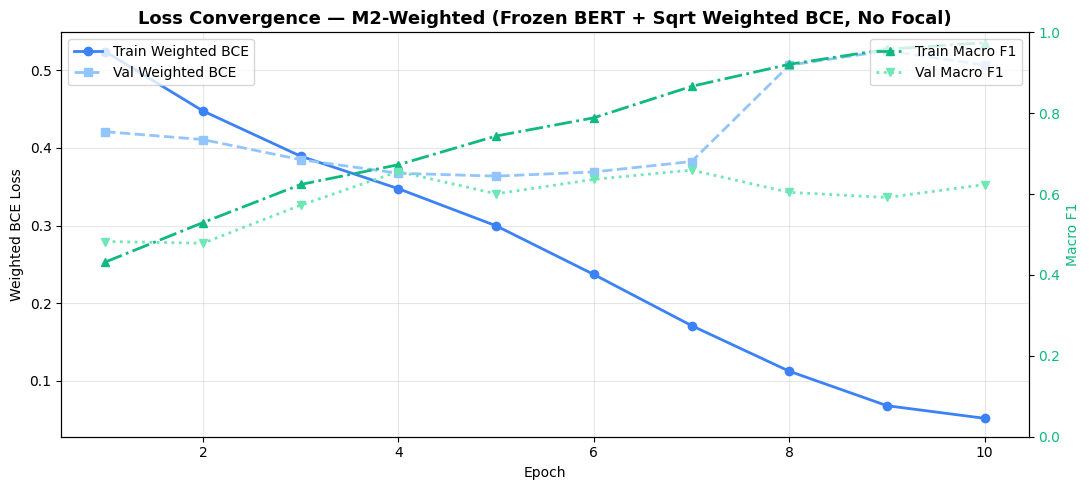

Saved: /kaggle/working/m2weighted_loss_convergence.png


In [21]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Weighted BCE', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Weighted BCE',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Weighted BCE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title('Loss Convergence — M2-Weighted (Frozen BERT + Sqrt Weighted BCE, No Focal)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [22]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(
    model, test_loader, device, pos_weight
)

print('\n' + '='*65)
print('TEST SET RESULTS — M2-Weighted (Frozen BERT + Weighted BCE)')
print('='*65)
print(f'Test Weighted BCE Loss : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 7


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS — M2-Weighted (Frozen BERT + Weighted BCE)
Test Weighted BCE Loss : 0.3633
Accuracy  (Pers. 2.15) : 0.7377
Macro Precision        : 0.6430
Macro Recall           : 0.6595
Macro F1   (Pers. 2.14): 0.6496


In [23]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)
avg_f1  = float(np.mean([r['f1'] for r in per_asp]))

print('\nPer-Aspect Results (sentiment-only, no_aspect excluded):')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results (sentiment-only, no_aspect excluded):
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.5679   0.5704   0.5909   0.7059    34
LONGEVITY        0.2727   0.2308   0.3333   0.6429    14
TEXTURE          0.8101   0.8175   0.8059   0.7619    21
HYDRATION        0.4649   0.4688   0.4630   0.7143    42
PRICE            1.0000   1.0000   1.0000   1.0000    11
-------------------------------------------------------
MACRO AVG        0.6231


In [24]:
flat_true   = test_true.flatten()
flat_pred   = test_pred.flatten()
active_mask = flat_true != -1

print('Global Classification Report (active slots, 3-class):')
print(classification_report(
    flat_true[active_mask], flat_pred[active_mask],
    target_names=SENTIMENTS, digits=4, zero_division=0
))

# Per-class recall — compare with M2 (no weight) to see weighting contribution
print('Per-class Recall (compare with M2 to verify weighting effect):')
for i, s in enumerate(SENTIMENTS):
    mask_cls = flat_true[active_mask] == i
    rec = (flat_pred[active_mask][mask_cls] == i).sum() / mask_cls.sum() if mask_cls.sum() > 0 else 0.0
    marker = ' ← minority' if s in ['negative', 'neutral'] else ''
    print(f'  {s:<10}: {float(rec):.4f}{marker}')

Global Classification Report (active slots, 3-class):
              precision    recall  f1-score   support

    negative     0.5758    0.6786    0.6230        28
     neutral     0.5000    0.5000    0.5000        14
    positive     0.8533    0.8000    0.8258        80

    accuracy                         0.7377       122
   macro avg     0.6430    0.6595    0.6496       122
weighted avg     0.7491    0.7377    0.7419       122

Per-class Recall (compare with M2 to verify weighting effect):
  negative  : 0.6786 ← minority
  neutral   : 0.5000 ← minority
  positive  : 0.8000


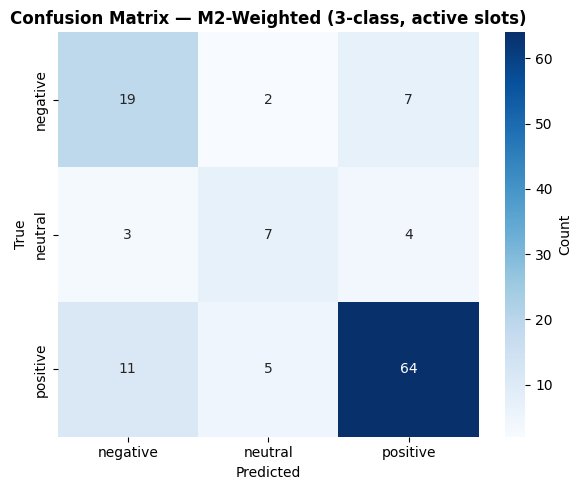

Saved: /kaggle/working/m2weighted_confusion_matrix.png


In [25]:
cm = confusion_matrix(flat_true[active_mask], flat_pred[active_mask], labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — M2-Weighted (3-class, active slots)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

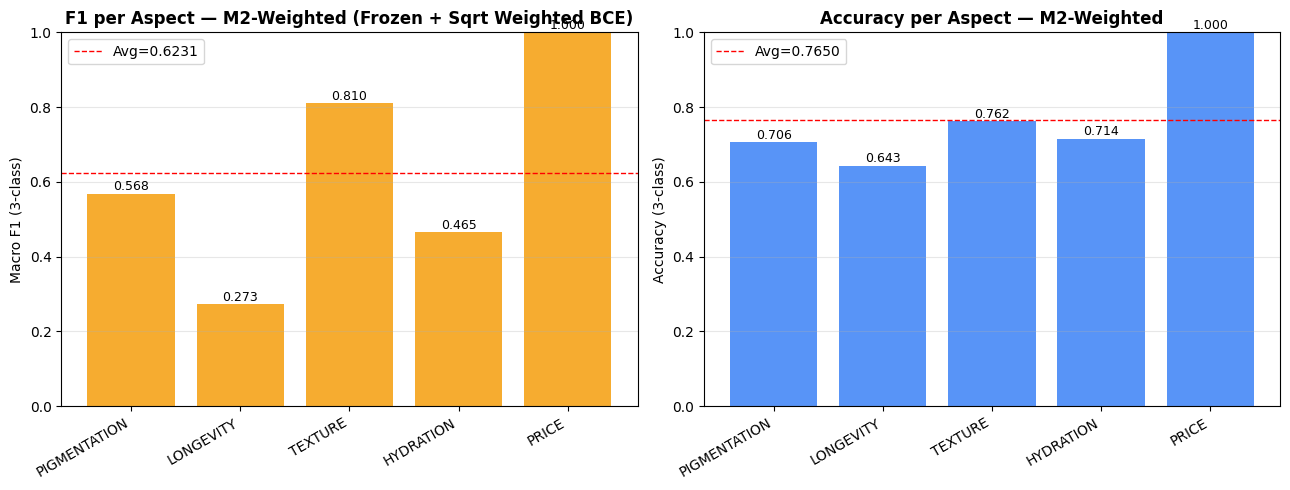

Saved: /kaggle/working/m2weighted_per_aspect_results.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

for ax, vals, ylabel, color in zip(
        axes,
        [[r['f1'] for r in per_asp], [r['accuracy'] for r in per_asp]],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#f59e0b', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M2-Weighted (Frozen + Sqrt Weighted BCE)', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M2-Weighted', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [27]:
D = test_true.shape[0]
L = test_true.shape[1]

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1-hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 32
Hamming Loss  : 32/250 = 0.1280
Hamming Acc   : 0.8720

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION           10   0.2000   0.8000
LONGEVITY               5   0.1000   0.9000
TEXTURE                 5   0.1000   0.9000
HYDRATION              12   0.2400   0.7600
PRICE                   0   0.0000   1.0000
--------------------------------------------
MACRO AVG                   0.1280   0.8720


---
## Section 13: Save Predictions & Metrics

In [28]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = [
    {
        'review_id' : test_df.iloc[i]['review_id'],
        'aspect'    : asp,
        'true_label': ID2SENT.get(test_true[i, j], 'no_aspect'),
        'pred_label': ID2SENT.get(test_pred[i, j], 'no_aspect'),
        'correct'   : test_true[i, j] == test_pred[i, j],
    }
    for i in range(len(test_df))
    for j, asp in enumerate(ASPECTS)
]
pd.DataFrame(pred_rows).to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'             : 'M2Weighted_CABiLSTM_IndoBERT_StrictFrozen_WeightedBCE_SqrtNorm',
    'ablation_note'     : 'Frozen BERT + class weighting only — no Focal Loss, no partial unfreeze',
    'config'            : CONFIG,
    'bert_strategy'     : 'strict_frozen — ALL 12 layers frozen',
    'class_weights'     : {
        'strategy'      : 'sqrt_normalized',
        'reference'     : 'Mahajan et al. (2018)',
        'formula'       : 'sqrt(N_total / N_c), normalized to mean=1.0',
        'sent_counts'   : sent_counts,
        'total_sentiment': int(total_sent),
        'raw_weights'   : {s: float(w) for s, w in raw_weights.items()},
        'norm_weights'  : {s: float(w) for s, w in norm_weights.items()},
    },
    'focal_gamma'       : None,
    'best_epoch'        : int(best_epoch),
    'best_val_f1'       : float(best_val_f1),
    'test_loss'         : float(test_loss),
    'test_accuracy'     : float(test_m['accuracy']),
    'test_macro_f1'     : float(test_m['macro_f1']),
    'test_macro_prec'   : float(test_m['macro_prec']),
    'test_macro_rec'    : float(test_m['macro_rec']),
    'per_aspect'        : per_asp,
    'avg_per_aspect_f1' : float(avg_f1),
    'hamming_loss'      : {
        'formula'          : 'Proposal Persamaan 2.16',
        'D_reviews'        : int(D),
        'L_aspects'        : int(L),
        'overall'          : float(hamming_loss),
        'hamming_accuracy' : float(1 - hamming_loss),
        'per_aspect'       : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M2-Weighted complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m2weighted_predictions.csv
Metrics  saved: /kaggle/working/m2weighted_metrics.json

✅ M2-Weighted complete — Test Macro F1: 0.6496
